# Method 1: Calculate Wavelength Shift from Sun Spectrum

# 1. Load Synthetic spectrum from CF

In [1]:
import numpy as np

calibration_file = (r"C:\Users\sciglob\OneDrive - UMBC\4. SciGlob\code\wavelength_shift_calculation\calibration_files\Pandora2s1_CF_v20d20240823.txt")

with open(calibration_file, "r", encoding="utf-8") as file:
    calibration_lines = file.readlines()

dispersion_polynomial = None
resolution_polynomial = None
reference_spectrum_open = None
synthetic_reference_wavelengths_open = None
synthetic_reference_spectrum_open = None

for line in calibration_lines:

    if line.startswith("Dispersion polynomial ->"):
        values_text = line.split("->", 1)[1]
        dispersion_polynomial = np.array(
            values_text.split(),
            dtype=float
        )

    elif line.startswith("Resolution polynomial ->"):
        values_text = line.split("->", 1)[1]
        resolution_polynomial = np.array(
            values_text.split(),
            dtype=float
        )

    elif line.startswith(
        "Wavelengths for synthetic reference spectrum for OPEN [nm] ->"
    ):
        values_text = line.split("->", 1)[1]
        synthetic_reference_wavelengths_open = np.array(
            values_text.split(),
            dtype=float
        )

    elif line.startswith("Synthetic reference spectrum for OPEN ->"):
        values_text = line.split("->", 1)[1]
        synthetic_reference_spectrum_open = np.array(
            values_text.split(),
            dtype=float
        )

number_of_pixels = 2048
pixels = np.arange(1, number_of_pixels + 1, dtype=float)
normalized_pixels = 3.46 * ((pixels / number_of_pixels) - 0.5)
wavelength = np.round(np.polyval(dispersion_polynomial, normalized_pixels), 4)

print("Dispersion polynomial:")
print(dispersion_polynomial)

print("\nResolution polynomial:")
print(resolution_polynomial)


print("\nArray shapes:")
print("Wavelength shape:", wavelength.shape)
print("Wavelengths for synthetic reference spectrum for OPEN shape:", synthetic_reference_wavelengths_open.shape)
print("Synthetic reference spectrum for OPEN shape:", synthetic_reference_spectrum_open.shape)

print("\nDetector wavelength range:")
print(f"{wavelength[0]:.4f} to {wavelength[-1]:.4f} nm")

print("\nSynthetic-reference wavelength range:")
print(f"{synthetic_reference_wavelengths_open[0]:.4f} to "
    f"{synthetic_reference_wavelengths_open[-1]:.4f} nm")

Dispersion polynomial:
[ 1.289070e-03 -1.018917e-03 -7.234850e-03  8.066126e-03 -1.277919e-01
 -2.566555e+00  7.737485e+01  4.177643e+02]

Resolution polynomial:
[ 1.481378  -1.059595   0.7612173]

Array shapes:
Wavelength shape: (2048,)
Wavelengths for synthetic reference spectrum for OPEN shape: (1984,)
Synthetic reference spectrum for OPEN shape: (1984,)

Detector wavelength range:
277.1268 to 543.2723 nm

Synthetic-reference wavelength range:
285.1304 to 541.9084 nm


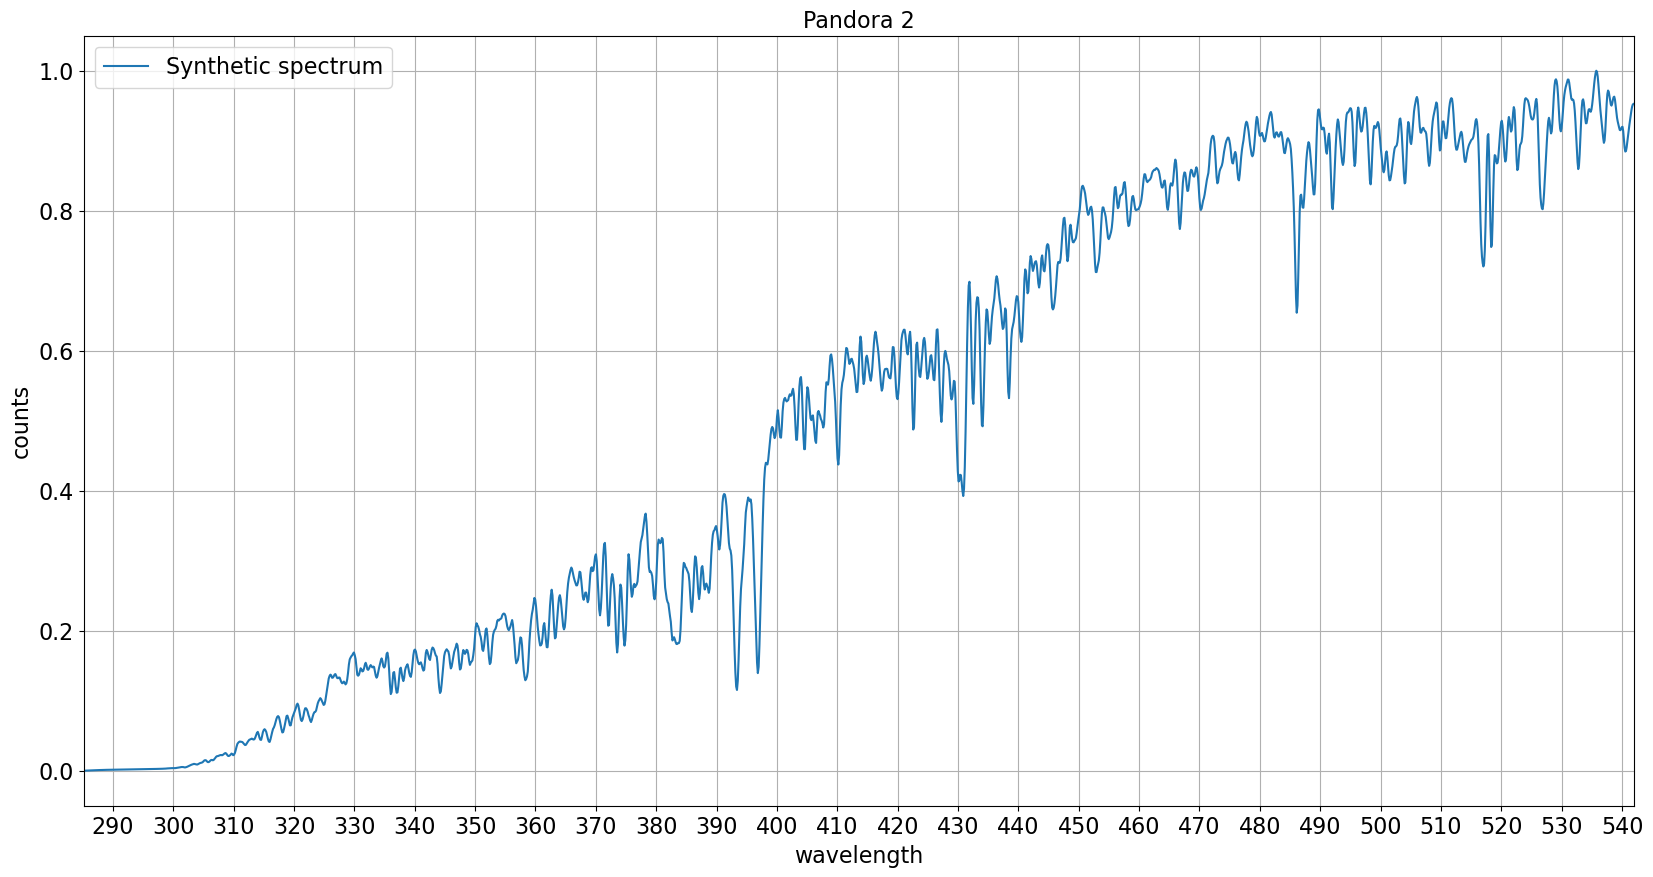

In [2]:
import matplotlib.pyplot as plt

def normalize(data):
    n = (data - min(data)) / (max(data)- min(data))
    return n
    
norm_synthetic_spec = normalize(synthetic_reference_spectrum_open)

plt.figure(figsize=(20, 10))
plt.plot(synthetic_reference_wavelengths_open, norm_synthetic_spec, label= 'Synthetic spectrum')
plt.yticks(fontsize=16)
plt.xticks(np.arange(280, 550, 10), fontsize=16)
plt.xlabel('wavelength',fontsize=16)
plt.ylabel('counts',fontsize=16)
plt.title('Pandora 2',fontsize=16)
plt.xlim(synthetic_reference_wavelengths_open[0], synthetic_reference_wavelengths_open[-1])
plt.legend(fontsize=16)
plt.grid(True)
plt.show()

# 2. Load L0 File

In [3]:
import numpy as np
import matplotlib.pyplot as plt

l0_file = r"C:\Users\sciglob\OneDrive - UMBC\4. SciGlob\code\wavelength_shift_calculation\L0\Pandora2s1_GreenbeltMD_20260720_L0.txt"

with open(l0_file, "r", encoding="utf-8", errors="replace") as file:
    lines = file.readlines()

separator_indices = [i for i, line in enumerate(lines) if line.strip().startswith("-----")]

if len(separator_indices) < 2:
    raise ValueError("The second metadata separator line was not found.")

data_start_index = separator_indices[1] + 1
data_lines = lines[data_start_index:]

print(f"Total lines after the second separator: {len(data_lines)}")

Total lines after the second separator: 5228


# 3. Extract SQ Routine

In [4]:
import re

routine_code = "SQ"
opaque_filterwheel_2_position = 3
number_of_detector_pixels = 2048

metadata_lines = lines[separator_indices[0] + 1:separator_indices[1]]

column_index = {}

for line in metadata_lines:
    line = line.strip()

    single_column_match = re.match(r"^Column\s+(\d+):\s*(.+)$", line)
    column_range_match = re.match(r"^Columns\s+(\d+)-(\d+):\s*(.+)$", line)

    if single_column_match:
        column_number = int(single_column_match.group(1))
        description = single_column_match.group(2).lower()
        python_index = column_number - 1

        if "two letter code of measurement routine" in description:
            column_index["routine_code"] = python_index

        elif "ut date and time for beginning of measurement" in description:
            column_index["time"] = python_index

        elif description.startswith("routine count"):
            column_index["routine_count"] = python_index

        elif description.startswith("repetition count"):
            column_index["repetition_count"] = python_index

        elif "position of filterwheel #1" in description:
            column_index["filterwheel_1"] = python_index

        elif "position of filterwheel #2" in description:
            column_index["filterwheel_2"] = python_index

        elif "scale factor for data" in description:
            column_index["scale_factor"] = python_index

    elif column_range_match:
        first_column = int(column_range_match.group(1))
        last_column = int(column_range_match.group(2))
        description = column_range_match.group(3).lower()

        if "mean over all cycles of raw counts for each pixel" in description:
            column_index["spectrum_start"] = first_column - 1
            column_index["spectrum_end"] = last_column

required_columns = [
    "routine_code",
    "time",
    "routine_count",
    "repetition_count",
    "filterwheel_1",
    "filterwheel_2",
    "scale_factor",
    "spectrum_start",
    "spectrum_end"
]

missing_columns = [name for name in required_columns if name not in column_index]

if missing_columns:
    raise ValueError(f"Could not find these required columns in the L0 metadata: {missing_columns}")

available_spectrum_values = column_index["spectrum_end"] - column_index["spectrum_start"]

if available_spectrum_values < number_of_detector_pixels:
    raise ValueError(f"The file contains only {available_spectrum_values} mean-count values, but {number_of_detector_pixels} detector pixels were requested.")

print("Detected L0 column indices:")

for name, index in column_index.items():
    print(f"  {name}: {index}")


# =========================================================
# EXTRACT SQ MEASUREMENTS
# =========================================================
sq_measurements = []

minimum_required_columns = column_index["spectrum_start"] + number_of_detector_pixels

for line_number, line in enumerate(data_lines, start=data_start_index + 1):
    values = line.split()

    if not values:
        continue

    if len(values) <= column_index["routine_code"]:
        print(f"Skipping incomplete line {line_number}: routine-code column is missing")
        continue

    if values[column_index["routine_code"]] != routine_code:
        continue

    if len(values) < minimum_required_columns:
        print(f"Skipping incomplete line {line_number}: expected at least {minimum_required_columns} columns, found {len(values)}")
        continue

    measurement_time = values[column_index["time"]]
    routine_count = int(values[column_index["routine_count"]])
    repetition_count = int(values[column_index["repetition_count"]])
    filterwheel_1_position = int(values[column_index["filterwheel_1"]])
    filterwheel_2_position = int(values[column_index["filterwheel_2"]])
    scale_factor = float(values[column_index["scale_factor"]])

    if scale_factor == 0:
        print(f"Skipping line {line_number}: scale factor is zero")
        continue

    spectrum_start = column_index["spectrum_start"]
    spectrum_stop = spectrum_start + number_of_detector_pixels
    scaled_counts = np.asarray(values[spectrum_start:spectrum_stop], dtype=float)
    unscaled_counts = scaled_counts / scale_factor

    sq_measurements.append({
        "time": measurement_time,
        "routine_count": routine_count,
        "repetition_count": repetition_count,
        "filterwheel_1": filterwheel_1_position,
        "filterwheel_2": filterwheel_2_position,
        "scale_factor": scale_factor,
        "spectrum": unscaled_counts
    })

print(f"Total valid SQ measurements: {len(sq_measurements)}")

Detected L0 column indices:
  routine_code: 0
  time: 1
  routine_count: 2
  repetition_count: 3
  filterwheel_1: 8
  filterwheel_2: 9
  scale_factor: 22
  spectrum_start: 24
  spectrum_end: 2076
Skipping incomplete line 98: expected at least 2072 columns, found 17
Skipping incomplete line 104: expected at least 2072 columns, found 17
Skipping incomplete line 110: expected at least 2072 columns, found 17
Skipping incomplete line 116: expected at least 2072 columns, found 17
Skipping incomplete line 122: expected at least 2072 columns, found 17
Skipping incomplete line 129: expected at least 2072 columns, found 17
Skipping incomplete line 135: expected at least 2072 columns, found 17
Skipping incomplete line 139: expected at least 2072 columns, found 17
Skipping incomplete line 195: expected at least 2072 columns, found 17
Skipping incomplete line 242: expected at least 2072 columns, found 17
Skipping incomplete line 298: expected at least 2072 columns, found 17
Skipping incomplete line

# 4. Dark correction and normalization

In [5]:
bright_measurements = []
dark_measurements_by_routine = {}

for measurement in sq_measurements:
    routine_count = measurement["routine_count"]

    if measurement["filterwheel_2"] == opaque_filterwheel_2_position:
        if routine_count not in dark_measurements_by_routine:
            dark_measurements_by_routine[routine_count] = []

        dark_measurements_by_routine[routine_count].append(measurement)
    else:
        bright_measurements.append(measurement)

print(f"Bright SQ measurements: {len(bright_measurements)}")
print(f"Routine counts containing dark SQ measurements: {len(dark_measurements_by_routine)}")


corrected_measurements = []

for bright_measurement in bright_measurements:
    routine_count = bright_measurement["routine_count"]

    if routine_count not in dark_measurements_by_routine:
        print(f"No matching dark spectrum for routine count {routine_count}. Skipping this bright spectrum.")
        continue

    matching_dark_spectra = [measurement["spectrum"] for measurement in dark_measurements_by_routine[routine_count]]
    mean_dark_spectrum = np.mean(matching_dark_spectra, axis=0)
    corrected_spectrum = bright_measurement["spectrum"] - mean_dark_spectrum

    spectrum_min = np.nanmin(corrected_spectrum)
    spectrum_max = np.nanmax(corrected_spectrum)

    if spectrum_max <= spectrum_min:
        print(f"Routine count {routine_count} cannot be normalized. Skipping it.")
        continue

    normalized_spectrum = (corrected_spectrum - spectrum_min) / (spectrum_max - spectrum_min)

    corrected_measurements.append({
        "time": bright_measurement["time"],
        "routine_count": routine_count,
        "repetition_count": bright_measurement["repetition_count"],
        "filterwheel_1": bright_measurement["filterwheel_1"],
        "filterwheel_2": bright_measurement["filterwheel_2"],
        "bright_spectrum": bright_measurement["spectrum"],
        "dark_spectrum": mean_dark_spectrum,
        "corrected_spectrum": corrected_spectrum,
        "normalized_spectrum": normalized_spectrum
    })

print(f"Successfully dark-corrected spectra: {len(corrected_measurements)}")

Bright SQ measurements: 737
Routine counts containing dark SQ measurements: 114
Successfully dark-corrected spectra: 737


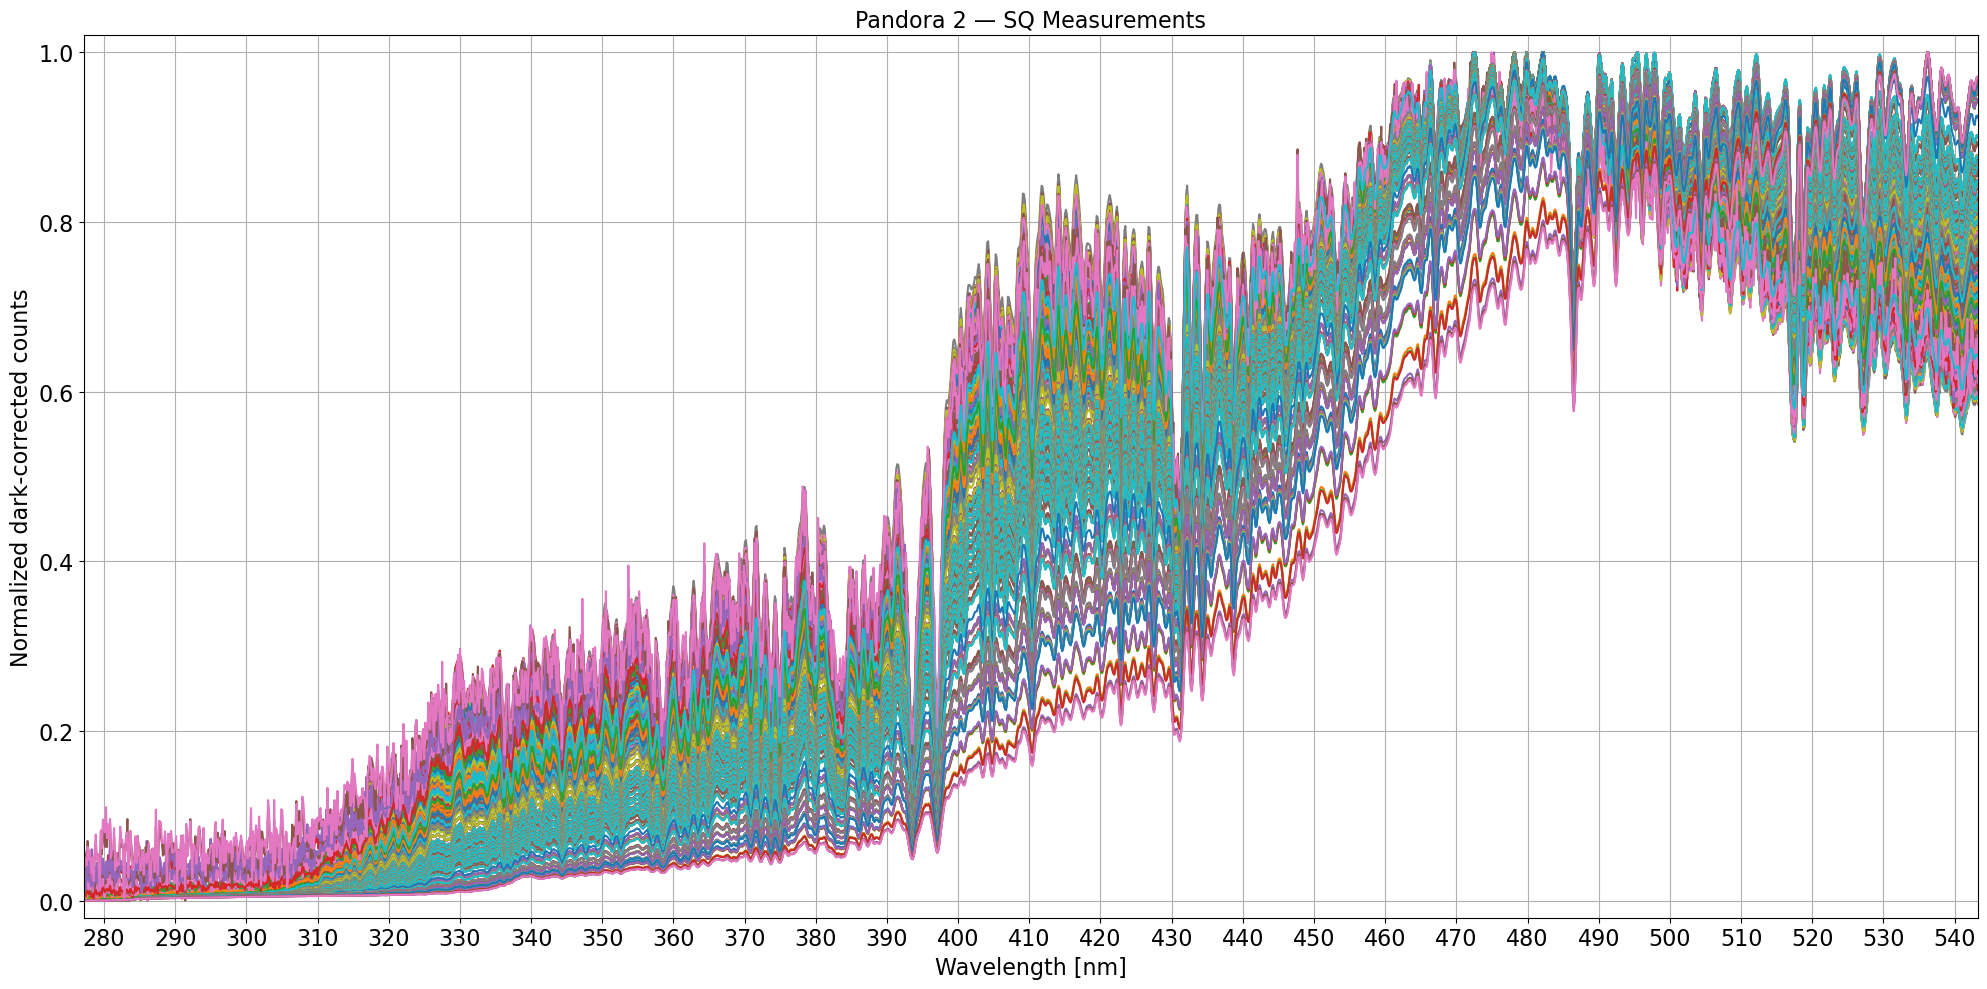

In [6]:
wavelength = np.asarray(wavelength, dtype=float)

if wavelength.shape != (number_of_detector_pixels,):
    raise ValueError(f"Expected wavelength shape ({number_of_detector_pixels},), but received {wavelength.shape}.")


plt.figure(figsize=(20, 10))

for measurement in corrected_measurements:
    label = f"Routine {measurement['routine_count']} | {measurement['time']}"
    plt.plot(wavelength, measurement["normalized_spectrum"], label=label)

plt.yticks(fontsize=16)
plt.xticks(np.arange(280, 550, 10), fontsize=16)
plt.xlabel("Wavelength [nm]", fontsize=16)
plt.ylabel("Normalized dark-corrected counts", fontsize=16)
plt.title("Pandora 2 — SQ Measurements", fontsize=16)
plt.xlim(wavelength[0], wavelength[-1])
plt.ylim(-0.02, 1.02)
# plt.legend(fontsize=11)
plt.grid(True)
plt.tight_layout()
plt.show()

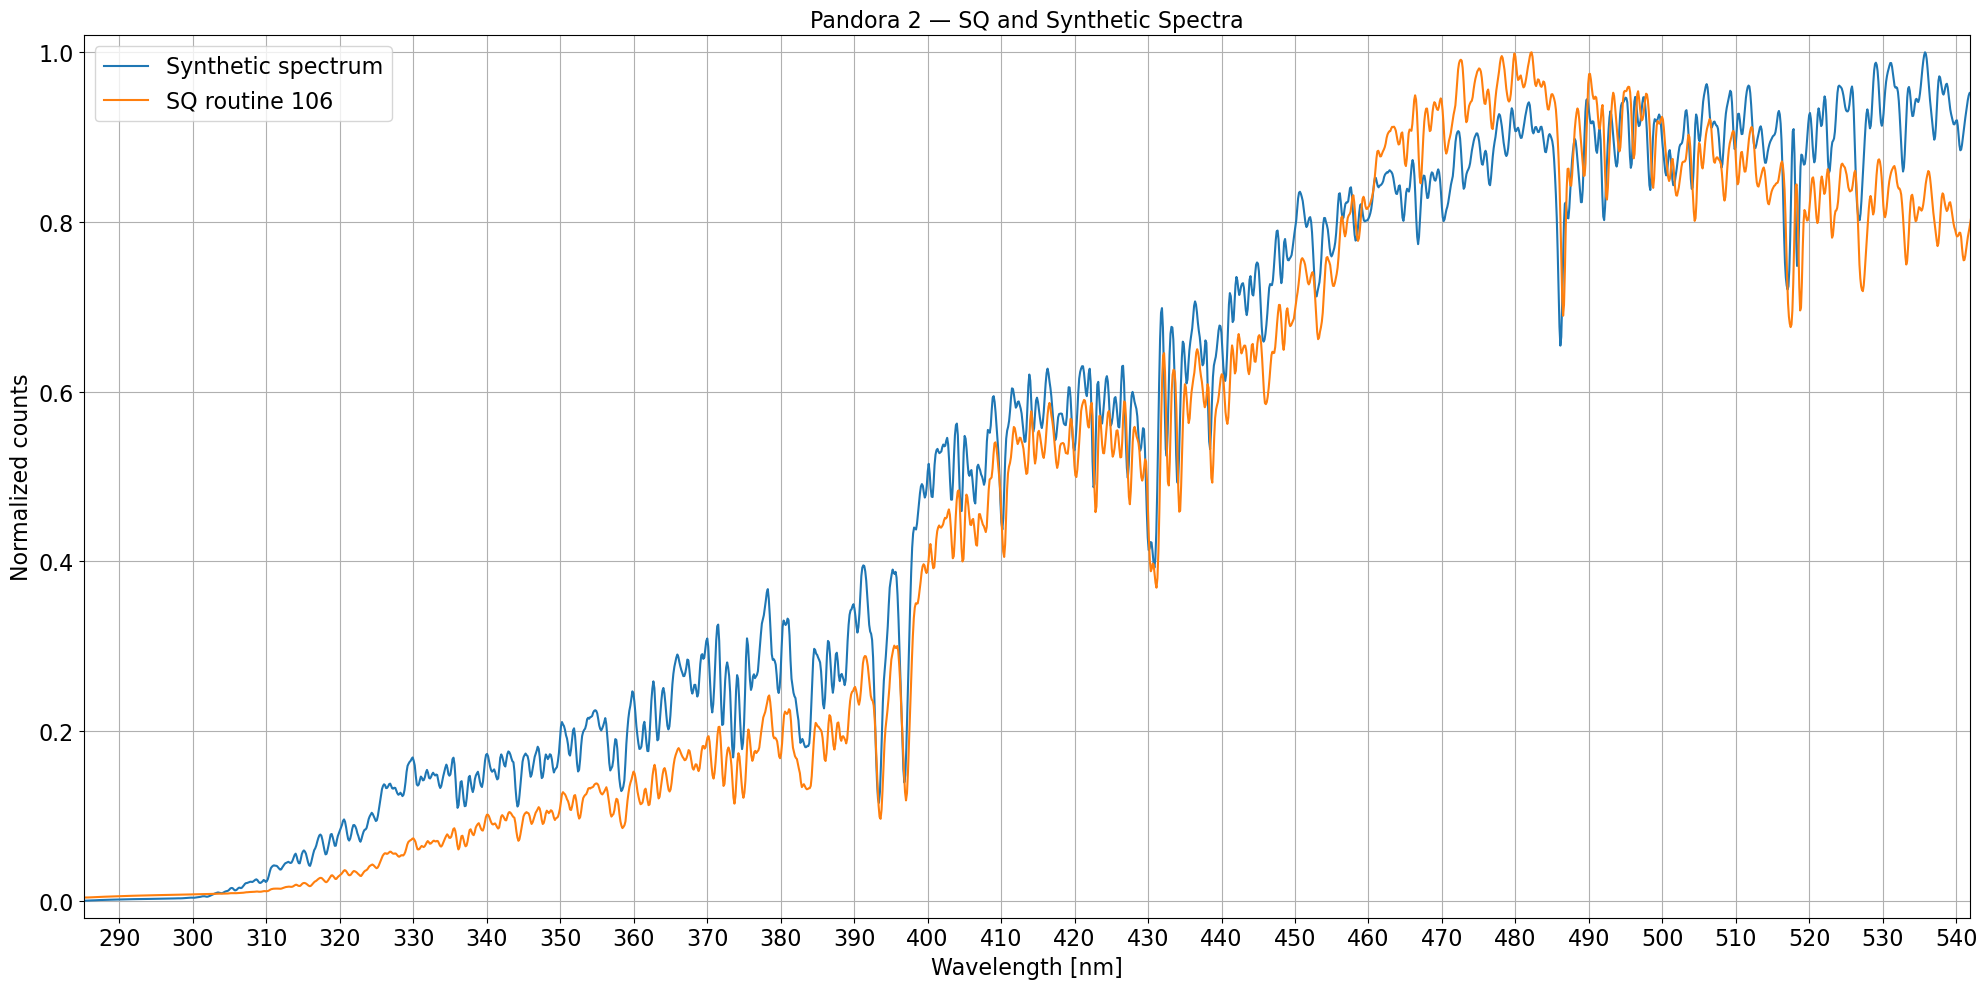

In [7]:

sq_spectrum_index = 100

selected_sq_measurement = corrected_measurements[sq_spectrum_index]
norm_sq_spectrum = selected_sq_measurement["normalized_spectrum"]

plt.figure(figsize=(20, 10))
plt.plot(synthetic_reference_wavelengths_open, norm_synthetic_spec, label="Synthetic spectrum")
plt.plot(wavelength, norm_sq_spectrum, label=f"SQ routine {selected_sq_measurement['routine_count']}")
plt.yticks(fontsize=16)
plt.xticks(np.arange(280, 550, 10), fontsize=16)
plt.xlabel("Wavelength [nm]", fontsize=16)
plt.ylabel("Normalized counts", fontsize=16)
plt.title("Pandora 2 — SQ and Synthetic Spectra", fontsize=16)
plt.xlim(synthetic_reference_wavelengths_open[0], synthetic_reference_wavelengths_open[-1])
plt.ylim(-0.02, 1.02)
plt.legend(fontsize=16)
plt.grid(True)
plt.tight_layout()
plt.show()

# 5. Wavelength Shift Calculation

In [8]:
import numpy as np


def calculate_wavelength_shift(
    reference_wavelength,
    reference_spectrum,
    measured_wavelength,
    measured_spectrum,
    fit_wavelength_min,
    fit_wavelength_max,
    shift_min_nm=-0.5,
    shift_max_nm=0.5,
    shift_step_nm=0.005
):
    """
    Calculate the constant wavelength shift between a reference spectrum
    and a measured spectrum using least-squares fitting.

    The function shifts the reference wavelength grid and interpolates the
    reference spectrum onto the measured wavelength grid.

    Positive returned shift:
        The reference spectrum must move toward longer wavelengths to align
        with the measured spectrum.

    Negative returned shift:
        The reference spectrum must move toward shorter wavelengths to align
        with the measured spectrum.

    Returns
    -------
    results : dict
        Dictionary containing the grid shift, refined shift, fitting error,
        scale factor, offset, residuals, and aligned spectra.
    """

    reference_wavelength = np.asarray(reference_wavelength, dtype=float)
    reference_spectrum = np.asarray(reference_spectrum, dtype=float)
    measured_wavelength = np.asarray(measured_wavelength, dtype=float)
    measured_spectrum = np.asarray(measured_spectrum, dtype=float)

    if reference_wavelength.ndim != 1 or reference_spectrum.ndim != 1:
        raise ValueError("Reference wavelength and spectrum must be one-dimensional arrays.")

    if measured_wavelength.ndim != 1 or measured_spectrum.ndim != 1:
        raise ValueError("Measured wavelength and spectrum must be one-dimensional arrays.")

    if len(reference_wavelength) != len(reference_spectrum):
        raise ValueError("Reference wavelength and spectrum must have the same length.")

    if len(measured_wavelength) != len(measured_spectrum):
        raise ValueError("Measured wavelength and spectrum must have the same length.")

    if fit_wavelength_min >= fit_wavelength_max:
        raise ValueError("fit_wavelength_min must be smaller than fit_wavelength_max.")

    if shift_min_nm >= shift_max_nm:
        raise ValueError("shift_min_nm must be smaller than shift_max_nm.")

    if shift_step_nm <= 0:
        raise ValueError("shift_step_nm must be greater than zero.")

    reference_valid = np.isfinite(reference_wavelength) & np.isfinite(reference_spectrum)
    measured_valid = np.isfinite(measured_wavelength) & np.isfinite(measured_spectrum)

    reference_wavelength = reference_wavelength[reference_valid]
    reference_spectrum = reference_spectrum[reference_valid]
    measured_wavelength = measured_wavelength[measured_valid]
    measured_spectrum = measured_spectrum[measured_valid]

    reference_sort_indices = np.argsort(reference_wavelength)
    measured_sort_indices = np.argsort(measured_wavelength)

    reference_wavelength = reference_wavelength[reference_sort_indices]
    reference_spectrum = reference_spectrum[reference_sort_indices]
    measured_wavelength = measured_wavelength[measured_sort_indices]
    measured_spectrum = measured_spectrum[measured_sort_indices]

    reference_unique_mask = np.concatenate(([True], np.diff(reference_wavelength) > 0))
    measured_unique_mask = np.concatenate(([True], np.diff(measured_wavelength) > 0))

    reference_wavelength = reference_wavelength[reference_unique_mask]
    reference_spectrum = reference_spectrum[reference_unique_mask]
    measured_wavelength = measured_wavelength[measured_unique_mask]
    measured_spectrum = measured_spectrum[measured_unique_mask]

    fit_mask = (measured_wavelength >= fit_wavelength_min) & (measured_wavelength <= fit_wavelength_max)
    fit_measured_wavelength = measured_wavelength[fit_mask]
    fit_measured_spectrum = measured_spectrum[fit_mask]

    if len(fit_measured_wavelength) < 10:
        raise ValueError("The selected fitting range contains fewer than 10 measured-spectrum points.")

    overlap_min = max(fit_wavelength_min, reference_wavelength[0] + shift_max_nm)
    overlap_max = min(fit_wavelength_max, reference_wavelength[-1] + shift_min_nm)
    common_fit_mask = (fit_measured_wavelength >= overlap_min) & (fit_measured_wavelength <= overlap_max)
    fit_measured_wavelength = fit_measured_wavelength[common_fit_mask]
    fit_measured_spectrum = fit_measured_spectrum[common_fit_mask]

    if len(fit_measured_wavelength) < 10:
        raise ValueError("The reference and measured spectra do not have enough common wavelengths for the requested shift range.")

    trial_shifts_nm = np.arange(shift_min_nm, shift_max_nm + shift_step_nm / 2, shift_step_nm)
    mean_squared_errors = np.full(len(trial_shifts_nm), np.nan)
    fitted_scale_factors = np.full(len(trial_shifts_nm), np.nan)
    fitted_offsets = np.full(len(trial_shifts_nm), np.nan)

    for shift_index, trial_shift_nm in enumerate(trial_shifts_nm):
        shifted_reference_wavelength = reference_wavelength + trial_shift_nm
        interpolated_reference = np.interp(fit_measured_wavelength, shifted_reference_wavelength, reference_spectrum)
        design_matrix = np.column_stack((interpolated_reference, np.ones(len(interpolated_reference))))
        coefficients, _, _, _ = np.linalg.lstsq(design_matrix, fit_measured_spectrum, rcond=None)

        scale_factor = coefficients[0]
        offset = coefficients[1]
        fitted_reference = scale_factor * interpolated_reference + offset
        residuals = fit_measured_spectrum - fitted_reference

        mean_squared_errors[shift_index] = np.mean(residuals ** 2)
        fitted_scale_factors[shift_index] = scale_factor
        fitted_offsets[shift_index] = offset

    if np.all(~np.isfinite(mean_squared_errors)):
        raise ValueError("No valid wavelength-shift solution was found.")

    best_shift_index = np.nanargmin(mean_squared_errors)
    best_grid_shift_nm = trial_shifts_nm[best_shift_index]
    refined_shift_nm = best_grid_shift_nm

    if 0 < best_shift_index < len(trial_shifts_nm) - 1:
        local_shifts = trial_shifts_nm[best_shift_index - 1:best_shift_index + 2]
        local_errors = mean_squared_errors[best_shift_index - 1:best_shift_index + 2]

        if np.all(np.isfinite(local_errors)):
            parabola_coefficients = np.polyfit(local_shifts, local_errors, 2)
            parabola_a = parabola_coefficients[0]
            parabola_b = parabola_coefficients[1]

            if parabola_a > 0:
                parabolic_shift_nm = -parabola_b / (2 * parabola_a)

                if local_shifts[0] <= parabolic_shift_nm <= local_shifts[-1]:
                    refined_shift_nm = parabolic_shift_nm

    shifted_reference_wavelength = reference_wavelength + refined_shift_nm
    aligned_reference_spectrum = np.interp(fit_measured_wavelength, shifted_reference_wavelength, reference_spectrum)
    final_design_matrix = np.column_stack((aligned_reference_spectrum, np.ones(len(aligned_reference_spectrum))))
    final_coefficients, _, _, _ = np.linalg.lstsq(final_design_matrix, fit_measured_spectrum, rcond=None)

    final_scale_factor = final_coefficients[0]
    final_offset = final_coefficients[1]
    fitted_reference_spectrum = final_scale_factor * aligned_reference_spectrum + final_offset
    residuals = fit_measured_spectrum - fitted_reference_spectrum
    final_mse = np.mean(residuals ** 2)
    residual_rmse = np.sqrt(final_mse)

    results = {
        "grid_shift_nm": best_grid_shift_nm,
        "refined_shift_nm": refined_shift_nm,
        "measured_wavelength_correction_nm": -refined_shift_nm,
        "mse": final_mse,
        "rmse": residual_rmse,
        "scale_factor": final_scale_factor,
        "offset": final_offset,
        "fit_wavelength": fit_measured_wavelength,
        "measured_spectrum": fit_measured_spectrum,
        "aligned_reference_spectrum": aligned_reference_spectrum,
        "fitted_reference_spectrum": fitted_reference_spectrum,
        "residuals": residuals,
        "trial_shifts_nm": trial_shifts_nm,
        "mean_squared_errors": mean_squared_errors,
        "trial_scale_factors": fitted_scale_factors,
        "trial_offsets": fitted_offsets
    }

    return results

In [9]:
selected_measurement = corrected_measurements[100]

shift_results = calculate_wavelength_shift(
    reference_wavelength=synthetic_reference_wavelengths_open,
    reference_spectrum=norm_synthetic_spec,
    measured_wavelength=wavelength,
    measured_spectrum=selected_measurement["normalized_spectrum"],
    fit_wavelength_min=390.0,
    fit_wavelength_max=520.0,
    shift_min_nm=-0.5,
    shift_max_nm=0.5,
    shift_step_nm=0.005
)

print(f"Best grid shift: {shift_results['grid_shift_nm']:+.4f} nm")
print(f"Refined reference shift: {shift_results['refined_shift_nm']:+.4f} nm")
print(f"Measured wavelength correction: {shift_results['measured_wavelength_correction_nm']:+.4f} nm")
print(f"RMSE: {shift_results['rmse']:.6e}")

Best grid shift: +0.3150 nm
Refined reference shift: +0.3165 nm
Measured wavelength correction: -0.3165 nm
RMSE: 4.394478e-02


In [10]:
from datetime import datetime, timezone, timedelta
import matplotlib.dates as mdates

# =========================================================
# WAVELENGTH-SHIFT SETTINGS
# =========================================================
fit_wavelength_min = 390.0
fit_wavelength_max = 520.0
shift_min_nm = -0.5
shift_max_nm = 0.5
shift_step_nm = 0.005


wavelength_shift_results = []

for measurement_number, measurement in enumerate(corrected_measurements):
    try:
        shift_result = calculate_wavelength_shift(
            reference_wavelength=synthetic_reference_wavelengths_open,
            reference_spectrum=norm_synthetic_spec,
            measured_wavelength=wavelength,
            measured_spectrum=measurement["normalized_spectrum"],
            fit_wavelength_min=fit_wavelength_min,
            fit_wavelength_max=fit_wavelength_max,
            shift_min_nm=shift_min_nm,
            shift_max_nm=shift_max_nm,
            shift_step_nm=shift_step_nm
        )

        wavelength_shift_results.append({
            "time": measurement["time"],
            "routine_count": measurement["routine_count"],
            "repetition_count": measurement["repetition_count"],
            "grid_shift_nm": shift_result["grid_shift_nm"],
            "refined_shift_nm": shift_result["refined_shift_nm"],
            "measured_wavelength_correction_nm": shift_result["measured_wavelength_correction_nm"],
            "mse": shift_result["mse"],
            "rmse": shift_result["rmse"]
        })

        print(
            f"{measurement_number + 1}/{len(corrected_measurements)} | "
            f"Time: {measurement['time']} | "
            f"Routine: {measurement['routine_count']} | "
            f"Reference shift: {shift_result['refined_shift_nm']:+.4f} nm | "
            f"Measured correction: {shift_result['measured_wavelength_correction_nm']:+.4f} nm"
        )

    except Exception as error:
        print(
            f"Could not calculate shift for measurement {measurement_number + 1}, "
            f"routine {measurement['routine_count']}, time {measurement['time']}: {error}"
        )

print(f"Successfully calculated wavelength shifts: {len(wavelength_shift_results)}")



1/737 | Time: 20260720T105940.5Z | Routine: 67 | Reference shift: +0.3392 nm | Measured correction: -0.3392 nm
2/737 | Time: 20260720T110431.2Z | Routine: 70 | Reference shift: +0.3388 nm | Measured correction: -0.3388 nm
3/737 | Time: 20260720T110445.6Z | Routine: 70 | Reference shift: +0.3388 nm | Measured correction: -0.3388 nm
4/737 | Time: 20260720T110459.9Z | Routine: 70 | Reference shift: +0.3386 nm | Measured correction: -0.3386 nm
5/737 | Time: 20260720T110514.3Z | Routine: 70 | Reference shift: +0.3386 nm | Measured correction: -0.3386 nm
6/737 | Time: 20260720T111019.2Z | Routine: 73 | Reference shift: +0.3364 nm | Measured correction: -0.3364 nm
7/737 | Time: 20260720T111029.0Z | Routine: 73 | Reference shift: +0.3364 nm | Measured correction: -0.3364 nm
8/737 | Time: 20260720T111038.7Z | Routine: 73 | Reference shift: +0.3363 nm | Measured correction: -0.3363 nm
9/737 | Time: 20260720T111048.5Z | Routine: 73 | Reference shift: +0.3363 nm | Measured correction: -0.3363 nm
1

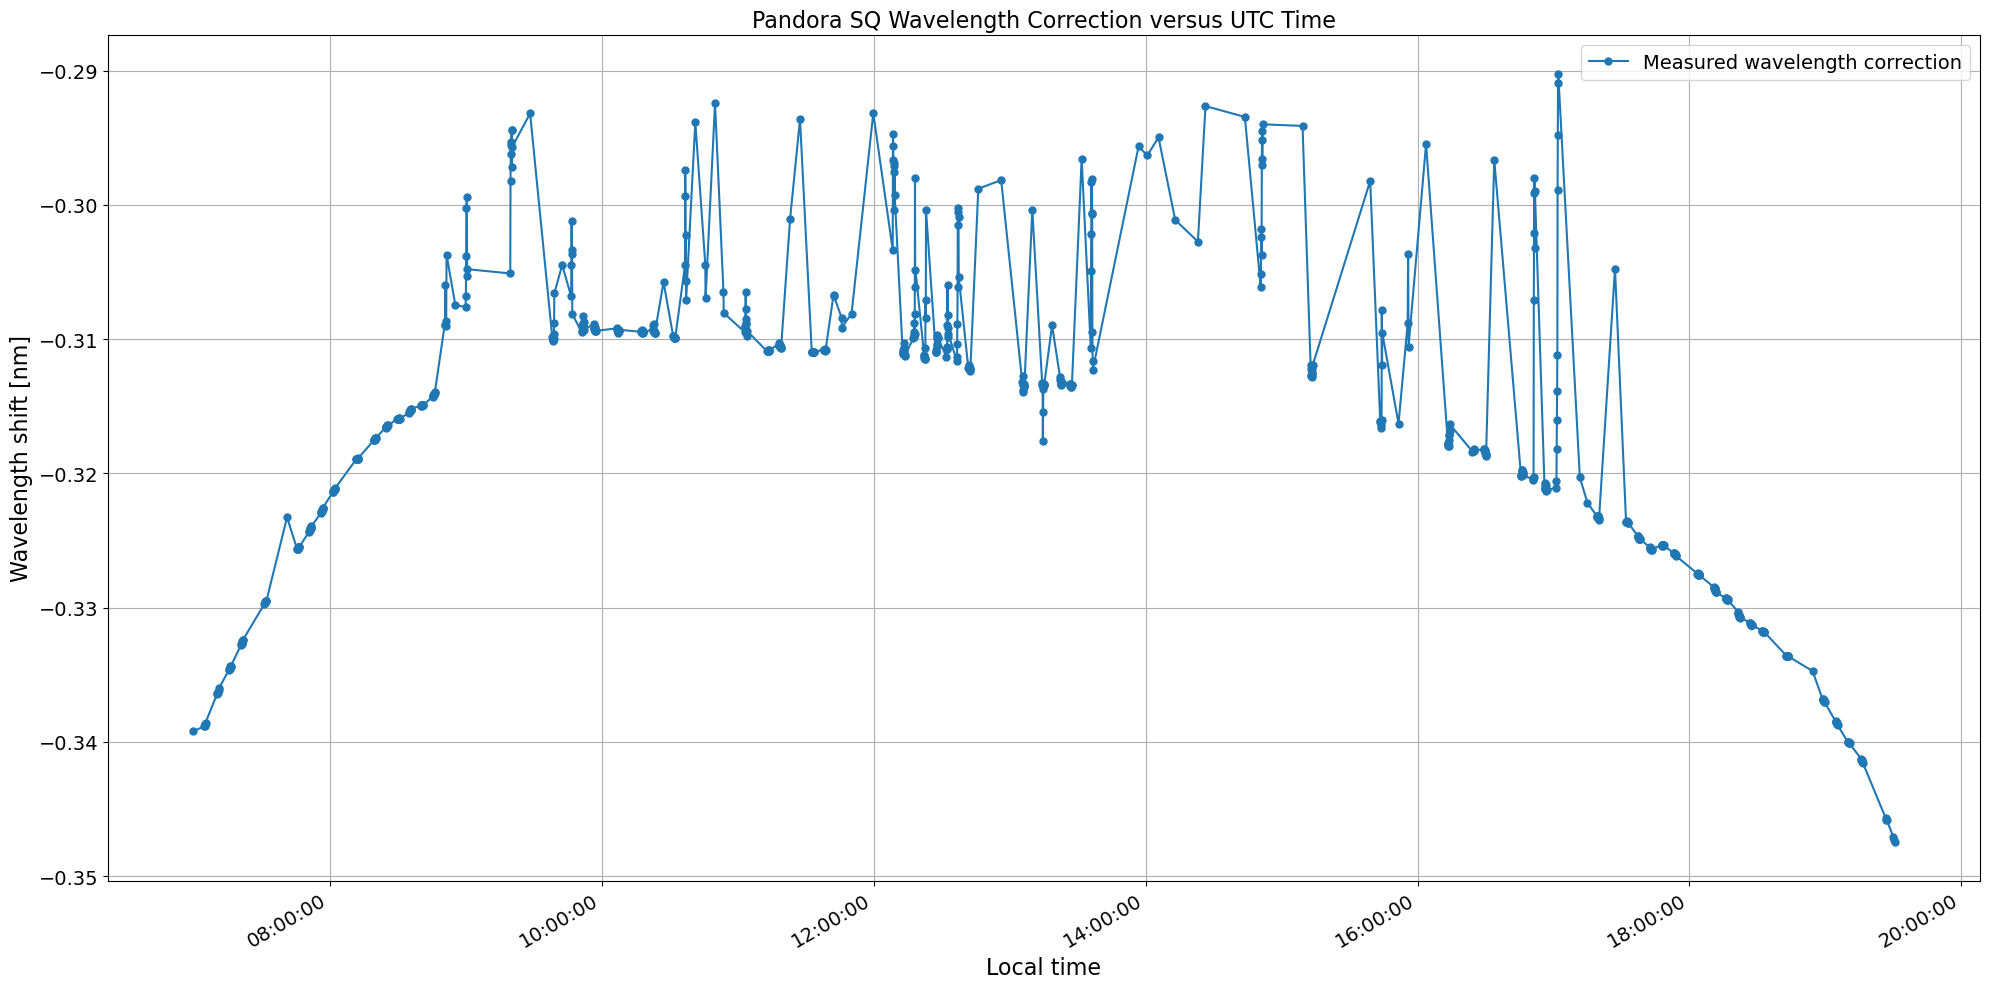

In [11]:
plot_times = []
plot_corrections = []
plot_reference_shifts = []
plot_rmse = []
plot_routine_counts = []

for result in wavelength_shift_results:
    time_text = str(result["time"]).strip()

    time_value = datetime.strptime(time_text, "%Y%m%dT%H%M%S.%fZ")
    time_value = time_value.replace(tzinfo=timezone.utc)
    
    plot_times.append(time_value)
    plot_corrections.append(result["measured_wavelength_correction_nm"])
    plot_reference_shifts.append(result["refined_shift_nm"])
    plot_rmse.append(result["rmse"])
    plot_routine_counts.append(result["routine_count"])

sort_indices = np.argsort(plot_times)

plot_times = np.asarray(plot_times, dtype=object)[sort_indices]
plot_corrections = np.asarray(plot_corrections, dtype=float)[sort_indices]
plot_reference_shifts = np.asarray(plot_reference_shifts, dtype=float)[sort_indices]
plot_rmse = np.asarray(plot_rmse, dtype=float)[sort_indices]
plot_routine_counts = np.asarray(plot_routine_counts)[sort_indices]

local_timezone = timezone(timedelta(hours=-4))
plot_times_local = np.asarray([time_value.astimezone(local_timezone) for time_value in plot_times], dtype=object)


fig, ax = plt.subplots(figsize=(20, 10))

ax.plot(plot_times, plot_corrections, marker="o", markersize=5, linewidth=1.5, label="Measured wavelength correction")
ax.set_xlabel("Local time", fontsize=16)
ax.set_ylabel("Wavelength shift [nm]", fontsize=16)
ax.set_title("Pandora SQ Wavelength Correction versus UTC Time", fontsize=16)
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S", tz=local_timezone))

ax.tick_params(axis="both", labelsize=14)
ax.grid(True)
ax.legend(fontsize=14)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()